# JB_22 dose-day tinyRNN MF fit

This notebook uses tinyRNN's existing `MABCogAgent` and `CogAgentTrainer` directly.

Note: the built-in MF model in tinyRNN is a two-step-style choice/outcome model. I keep `stimulus` in the session dict for reference, but this specific MF likelihood only consumes `choices`, `second_steps`, and `outcomes`.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
tinyrnn_root = Path('/Users/hunglo/Documents/GitHub/tinyRNN').resolve()

assert tinyrnn_root.exists(), tinyrnn_root

# Make sure tinyRNN imports resolve before anything else.
for p in [tinyrnn_root, repo_root]:
    ps = str(p)
    if ps not in sys.path:
        sys.path.insert(0, ps)

import path_settings
import agents.BaseAgent as base_agent_mod
import agents.CogAgent as cog_agent_mod
import agents.CogAgentTrainer as cog_trainer_mod

# Save tinyRNN outputs inside this repo so the notebook stays writable here.
save_root = repo_root / 'tinyRNN_saved_model'
path_settings.MODEL_SAVE_PATH = save_root
base_agent_mod.MODEL_SAVE_PATH = save_root
cog_agent_mod.MODEL_SAVE_PATH = save_root
cog_trainer_mod.MODEL_SAVE_PATH = save_root

from agents.MABCogAgent import MABCogAgent
from agents.CogAgentTrainer import CogAgentTrainer

print('repo_root:', repo_root)
print('tinyrnn_root:', tinyrnn_root)
print('save_root:', save_root)
print('Python:', sys.executable)

repo_root: /Users/hunglo/Documents/GitHub/RNN_modeling
tinyrnn_root: /Users/hunglo/Documents/GitHub/tinyRNN
save_root: /Users/hunglo/Documents/GitHub/RNN_modeling/tinyRNN_saved_model
Python: /opt/anaconda3/envs/tinyrnn/bin/python


mouse: JB_22
session_idx: 4
session_date: 2025-10-31
n_trials: 500
stimulus unique: [-1  1]
choice unique: [0 1]
reward unique: [-1.  0.  1.]
Go trials: 250
NoGo trials: 250


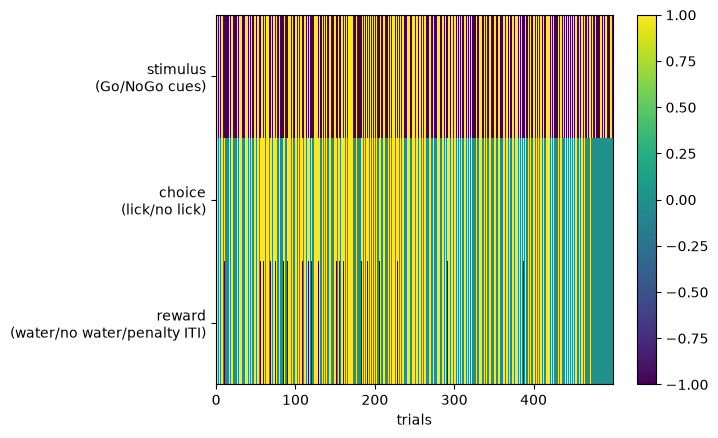

In [2]:
## get desing matrix
bundle_path = repo_root / 'codex_proecessed_data' / 'mf_preprocessed' / 'JB_22_sessionwise_mf.npz'
bundle = np.load(bundle_path, allow_pickle=True)

session_idx = 4
stimulus = np.asarray(bundle['stimulus_by_session'][session_idx], dtype=np.int64)
choice = np.asarray(bundle['choice_by_session'][session_idx], dtype=np.int64)
reward = np.asarray(bundle['reward_by_session'][session_idx], dtype=np.float64)

# tinyRNN's MF model expects action/state alignment, so we use response as both.
session = {
    'choices': choice,
    'second_steps': choice.copy(),
    'outcomes': reward,
    'n_trials': int(len(choice)),
    'mask': np.ones(len(choice), dtype=np.int64),
    'stimulus': stimulus,
}

data = {
    'train': {'input': [session]},
    'val': {'input': [session]},
    'test': {'input': [session]},
}

print('mouse:', str(bundle['mouse_id']))
print('session_idx:', session_idx)
print('session_date:', str(bundle['session_date'][session_idx]))
print('n_trials:', len(choice))
print('stimulus unique:', np.unique(stimulus))
print('choice unique:', np.unique(choice))
print('reward unique:', np.unique(reward))
print('Go trials:', int((stimulus > 0).sum()))
print('NoGo trials:', int((stimulus < 0).sum()))

plt.imshow(np.vstack([stimulus,choice,reward]),aspect='auto',interpolation='none')
plt.yticks([0,1,2],['stimulus\n(Go/NoGo cues)','choice\n(lick/no lick)','reward\n(water/no water/penalty ITI)'])
plt.colorbar()
plt.xlabel('trials')
plt.show()

In [3]:
mf = MABCogAgent({
    'cog_type': 'MF',
    'n_actions': 2,
    'model_path': 'jb22_dose_day_mf_tinyrnn',
    'save_model_pass': 'minimal',
})

trainer = CogAgentTrainer(mf)

print('param names:', trainer.model.param_names)
print('initial params:', trainer.model.params)
print('trainer class:', type(trainer))

param names: ['alpha', 'iTemp']
initial params: [0.5, 5.0]
trainer class: <class 'agents.CogAgentTrainer.CogAgentTrainer'>


In [9]:
trainer.train(data=data, verbose_level=1)

fit_summary = pd.DataFrame({
    'param_name': trainer.model.param_names,
    'param_value': trainer.model.params,
})
fit_summary


Model jb22_dose_day_mf_tinyrnn Training done. time cost: 0.13047289848327637 train loss: 0.6931471805599453 val loss: 0.6931471805599453 test loss: 0.6931471805599453


,param_name,param_value
0,alpha,1.931726e-05
1,iTemp,1.780443e-15


In [10]:
## get total loglikelihood
# trainer.best_model_pass["train"]["behav_loss"]
train_pass = trainer.best_model_pass["train"]
total_ll = -train_pass["behav_loss"] * train_pass["total_trial_num"]
total_ll

-13.862943611198906

In [11]:
print('train behav_loss:', trainer.best_model_pass['train']['behav_loss'])
print('val behav_loss:', trainer.best_model_pass['val']['behav_loss'])
print('test behav_loss:', trainer.best_model_pass['test']['behav_loss'])
# print('saved to:', save_root / 'jb22_dose_day_mf_tinyrnn')

train behav_loss: 0.6931471805599453
val behav_loss: 0.6931471805599453
test behav_loss: 0.6931471805599453


In [16]:
## sliding window 50 trials no overlaps
window_size = 20
fit_summary_sliding = pd.DataFrame()
total_ll_slide = []

for window in np.arange(0,len(stimulus),window_size):
    # print(window)
    # tinyRNN's MF model expects action/state alignment, so we use response as both.
    # make a mask here for the sliding window
    mask = np.zeros(len(choice)).astype(np.int64)
    mask[window:window+window_size] = 1
    # plt.figure(figsize=[3,2])
    # plt.imshow([mask],aspect='auto')
    # plt.show()
    session = {
        'choices': choice,
        'second_steps': choice.copy(),
        'outcomes': reward,
        'n_trials': int(len(choice)),
        'mask': mask,
        'stimulus': stimulus,
    }

    data = {
        'train': {'input': [session]},
        'val': {'input': [session]},
        'test': {'input': [session]},
    }
    
    mf = MABCogAgent({
        'cog_type': 'MF',
        'n_actions': 2,
        'model_path': 'jb22_dose_day_mf_tinyrnn',
        'save_model_pass': 'minimal',
    })

    trainer = CogAgentTrainer(mf)

    # print('param names:', trainer.model.param_names)
    # print('initial params:', trainer.model.params)
    # print('trainer class:', type(trainer))
    trainer.train(data=data, verbose_level=0)

    fit_summary = pd.DataFrame({
        'param_name': trainer.model.param_names,
        'param_value': trainer.model.params,
        'window':window+window_size//2
    })
    fit_summary_sliding = pd.concat([fit_summary_sliding,fit_summary],ignore_index=True)

    train_pass = trainer.best_model_pass["train"]
    total_ll = -train_pass["behav_loss"] * train_pass["total_trial_num"]
    total_ll_slide.append(total_ll)

fit_summary_sliding.head()

,param_name,param_value,window
0,alpha,1.000000e+00,10
1,iTemp,5.389965e-01,10
2,alpha,1.931726e-05,30
3,iTemp,1.780443e-15,30
4,alpha,1.125380e-07,50


Text(0.5, 0, 'trials')

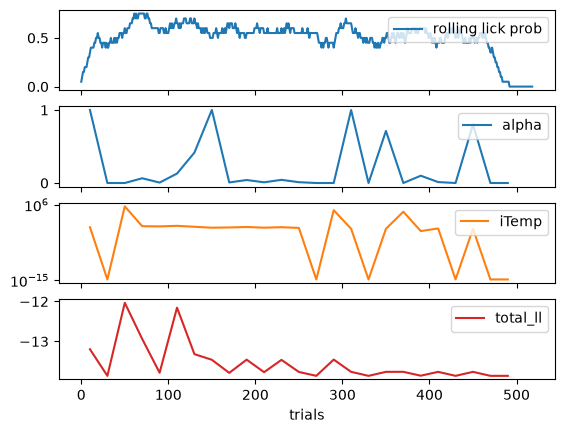

In [17]:
fig, axes = plt.subplots(nrows=4,sharey=False,sharex=True)
# axes[0].eventplot(np.where(stimulus == 1)[0],label='Go trial')
# axes[0].eventplot(np.where(choice == 1)[0],lineoffset=2,colors='C1',label='lick')
axes[0].plot(np.convolve(choice,np.ones(window_size))/window_size,label='rolling lick prob')
axes[0].legend(loc=1)
for idx, param in enumerate(fit_summary_sliding.param_name.unique()):
    ax = axes[idx+1]
    data_select = fit_summary_sliding[fit_summary_sliding['param_name']==param]
    ax.plot(data_select['window'],data_select['param_value'],label=param,c=f'C{idx}')
    ax.legend(loc=1)
    if idx==1:
        ax.set_yscale("log")
axes[3].plot(data_select['window'],total_ll_slide,label='total_ll',c='C3')
axes[3].legend()
axes[3].set_xlabel('trials')